# aer

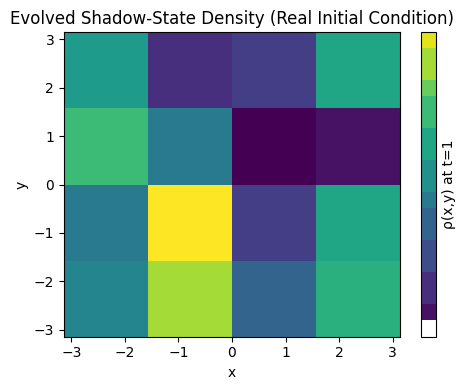

In [130]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# --- Parameters ---
N = 4  # Grid size
num_points = N * N
num_obs = 3
dim = num_points * num_obs
num_qubits = 6  # 2^6 = 64

# --- Generate vortex field using Madelung transformation ---
x = np.linspace(-np.pi, np.pi, N, endpoint=False)
y = np.linspace(-np.pi, np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)

x0, y0 = 0, 0
sigma = 1.0
R = np.sqrt((X - x0)**2 + (Y - y0)**2)
f = np.exp(-(R / sigma)**4)

u = 2 * (X + 1j * Y) * f / (1 + R**2)
v = 1j * (R**2 + 1 - 2 * f) / (1 + R**2)

psi1 = u / np.sqrt(np.abs(u)**2 + np.abs(v)**4)
psi2 = v**2 / np.sqrt(np.abs(u)**2 + np.abs(v)**4)

# --- Compute density and momentum components ---
kx = np.fft.fftfreq(N) * N
ky = np.fft.fftfreq(N) * N
KX, KY = np.meshgrid(kx, ky)

psi1_spec = np.fft.fft2(psi1)
dpsi1_x = np.fft.ifft2(1j * KX * psi1_spec)
dpsi1_y = np.fft.ifft2(1j * KY * psi1_spec)

psi2_spec = np.fft.fft2(psi2)
dpsi2_x = np.fft.ifft2(1j * KX * psi2_spec)
dpsi2_y = np.fft.ifft2(1j * KY * psi2_spec)

rho = np.abs(psi1)**2 + np.abs(psi2)**2
ux = np.real(np.real(psi1)*np.imag(dpsi1_x) - np.imag(psi1)*np.real(dpsi1_x)
             + np.real(psi2)*np.imag(dpsi2_x) - np.imag(psi2)*np.real(dpsi2_x)) / rho
uy = np.real(np.real(psi1)*np.imag(dpsi1_y) - np.imag(psi1)*np.real(dpsi1_y)
             + np.real(psi2)*np.imag(dpsi2_y) - np.imag(psi2)*np.real(dpsi2_y)) / rho

# --- Flatten to form initial shadow state ---
rho_vec = rho.flatten()
ux_vec = ux.flatten()
uy_vec = uy.flatten()
shadow_state = np.concatenate([rho_vec, ux_vec, uy_vec])
shadow_state /= np.linalg.norm(shadow_state)

# --- Construct H_S ---
def idx(x, y):
    return (x % N) + (y % N) * N

data, rows, cols = [], [], []
for y in range(N):
    for x in range(N):
        i = idx(x, y)
        i_rho = i
        i_jx = i + num_points
        i_jy = i + 2 * num_points

        for dx_shift, coeff in [(-1, 1), (1, -1)]:
            j = idx(x + dx_shift, y)
            j_jx = j + num_points
            data.append(coeff / (2 * (2 * np.pi / N)))
            rows.append(i_rho)
            cols.append(j_jx)

        for dy_shift, coeff in [(-1, 1), (1, -1)]:
            j = idx(x, y + dy_shift)
            j_jy = j + 2 * num_points
            data.append(coeff / (2 * (2 * np.pi / N)))
            rows.append(i_rho)
            cols.append(j_jy)

        for shift, coeff in [((0, 0), -4), ((1, 0), 1), ((-1, 0), 1), ((0, 1), 1), ((0, -1), 1)]:
            j = idx(x + shift[0], y + shift[1])
            j_rho = j
            data.append(coeff / (2 * np.pi / N)**2)
            rows.append(i_jx)
            cols.append(j_rho)
            data.append(coeff / (2 * np.pi / N)**2)
            rows.append(i_jy)
            cols.append(j_rho)

Hs = sp.csr_matrix((data, (rows, cols)), shape=(dim, dim))

# --- Diagonalize H_S ---
Hs_dense = Hs.toarray()
evals, evecs = np.linalg.eigh(Hs_dense)
t = 2.0
U_exact = evecs @ np.diag(np.exp(-1j * evals * t)) @ evecs.conj().T

# --- Embed into 64x64 space ---
U_padded = np.eye(2**num_qubits, dtype=complex)
U_padded[:dim, :dim] = U_exact

# --- Embed initial shadow state ---
psi0 = np.zeros(2**num_qubits, dtype=complex)
psi0[:dim] = shadow_state

# --- Simulate circuit ---
qc = QuantumCircuit(num_qubits)
qc.initialize(psi0, range(num_qubits))
qc.unitary(Operator(U_padded), range(num_qubits))
qc.save_statevector()

sim = AerSimulator(method="statevector")
compiled = transpile(qc, sim)
result = sim.run(compiled).result()
psi1 = result.get_statevector()

# --- Extract evolved rho(x,y) ---
rho_t = np.real(psi1.data[:num_points])
rho_t = rho_t.reshape((N, N))

# --- Plot ---
# 修复维度：添加边界使得 X, Y 是 (N+1, N+1)
x_edges = np.linspace(-np.pi, np.pi, N+1)
y_edges = np.linspace(-np.pi, np.pi, N+1)
X, Y = np.meshgrid(x_edges, y_edges)

plt.figure(figsize=(5, 4))
plt.pcolormesh(X, Y, rho_t, shading='auto', cmap='viridis')
plt.colorbar(label='ρ(x,y) at t=1')
plt.title('Evolved Shadow-State Density (Real Initial Condition)')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

